<a href="https://colab.research.google.com/github/Mounika-ajh/Mounika-ajh/blob/main/python_project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("/ecommerce_orders_lsb.csv")
df.head()

,OrderID,CustomerID,Product,Quantity,Price,OrderDate,Region,PaymentMethod
0,10001,C1023,Tablet,1,499.99,1/3/2025,Northeast,Credit Card
1,10002,C1045,Laptop,1,1099.99,1/5/2025,West,PayPal
2,10003,C1011,Headphones,2,149.99,1/6/2025,South,Debit Card
3,10004,C1098,Camera,1,799.99,1/7/2025,Midwest,Credit Card
4,10005,C1034,Smartwatch,1,299.99,1/8/2025,Northeast,Apple Pay


In [19]:
df['TotalAmount'] = df['Quantity'] * df['Price']
df.head()

,OrderID,CustomerID,Product,Quantity,Price,OrderDate,Region,PaymentMethod,TotalAmount
0,10001,C1023,Tablet,1,499.99,1/3/2025,Northeast,Credit Card,499.99
1,10002,C1045,Laptop,1,1099.99,1/5/2025,West,PayPal,1099.99
2,10003,C1011,Headphones,2,149.99,1/6/2025,South,Debit Card,299.98
3,10004,C1098,Camera,1,799.99,1/7/2025,Midwest,Credit Card,799.99
4,10005,C1034,Smartwatch,1,299.99,1/8/2025,Northeast,Apple Pay,299.99


In [20]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [21]:
df['Product'].unique()

array(['Tablet', 'Laptop', 'Headphones', 'Camera', 'Smartwatch',
       'Mobile phone'], dtype=object)

In [22]:
df.groupby('CustomerID')['OrderID'].count()

,OrderID
CustomerID,
C1003,1
C1004,1
C1005,1
C1006,1
C1007,1
...,...
C1125,1
C1127,1
C1129,1


In [23]:
df.groupby('Region')['TotalAmount'].mean()

,TotalAmount
Region,
Midwest,851.9856
Northeast,775.5840
South,799.1852
West,911.5856


In [24]:
filtered = df[(df['OrderDate'] >= '2025-01-01') &
              (df['OrderDate'] <= '2025-03-31')]

filtered

,OrderID,CustomerID,Product,Quantity,Price,OrderDate,Region,PaymentMethod,TotalAmount
0,10001,C1023,Tablet,1,499.99,2025-01-03,Northeast,Credit Card,499.99
1,10002,C1045,Laptop,1,1099.99,2025-01-05,West,PayPal,1099.99
2,10003,C1011,Headphones,2,149.99,2025-01-06,South,Debit Card,299.98
3,10004,C1098,Camera,1,799.99,2025-01-07,Midwest,Credit Card,799.99
4,10005,C1034,Smartwatch,1,299.99,2025-01-08,Northeast,Apple Pay,299.99
...,...,...,...,...,...,...,...,...,...
74,10075,C1097,Laptop,1,1099.99,2025-03-27,South,Credit Card,1099.99
75,10076,C1059,Camera,1,699.99,2025-03-28,Midwest,PayPal,699.99
76,10077,C1116,Smartwatch,2,259.99,2025-03-29,West,Credit Card,519.98
77,10078,C1022,Mobile phone,1,999.99,2025-03-30,Northeast,Credit Card,999.99


In [25]:
df.sort_values(by='TotalAmount', ascending=False).head()

,OrderID,CustomerID,Product,Quantity,Price,OrderDate,Region,PaymentMethod,TotalAmount
8,10009,C1009,Laptop,2,1199.99,2025-01-13,West,Credit Card,2399.98
32,10033,C1082,Laptop,2,1049.99,2025-02-13,West,PayPal,2099.98
56,10057,C1084,Laptop,2,999.99,2025-03-09,West,Debit Card,1999.98
71,10072,C1064,Mobile phone,2,979.99,2025-03-24,Midwest,Credit Card,1959.98
53,10054,C1078,Mobile phone,2,949.99,2025-03-06,Northeast,PayPal,1899.98


In [26]:
df.groupby('OrderDate')['OrderID'].count()

,OrderID
OrderDate,
2025-01-03,1
2025-01-05,1
2025-01-06,1
2025-01-07,1
2025-01-08,1
...,...
2025-04-17,1
2025-04-18,1
2025-04-19,1


In [27]:
df.isnull().sum()

,0
OrderID,0
CustomerID,0
Product,0
Quantity,0
Price,0
OrderDate,0
Region,0
PaymentMethod,0
TotalAmount,0


In [28]:
df['Price'].fillna(df['Price'].mean(), inplace=True)

/tmp/ipython-input-194/3868442878.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].mean(), inplace=True)


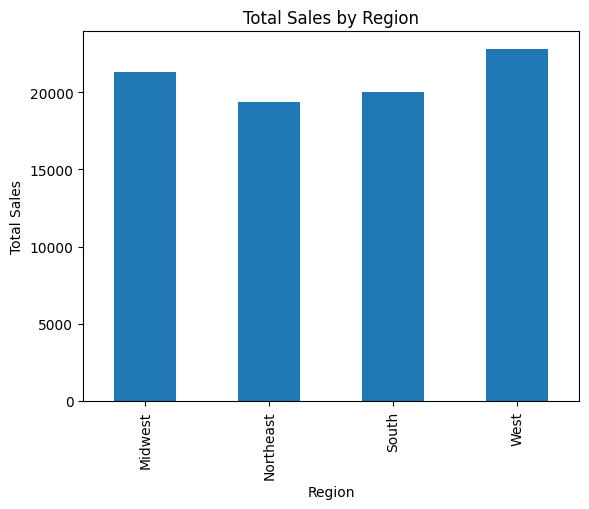

In [29]:
sales_region = df.groupby('Region')['TotalAmount'].sum()

sales_region.plot(kind='bar')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

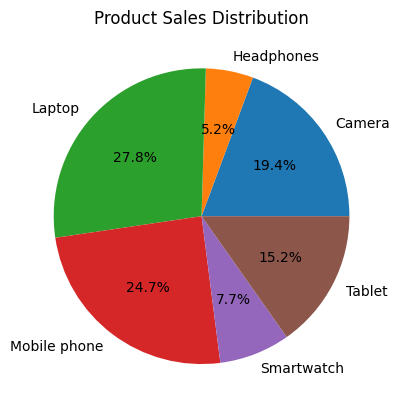

In [31]:
product_sales = df.groupby('Product')['TotalAmount'].sum()

product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Sales Distribution")
plt.ylabel("")
plt.show()

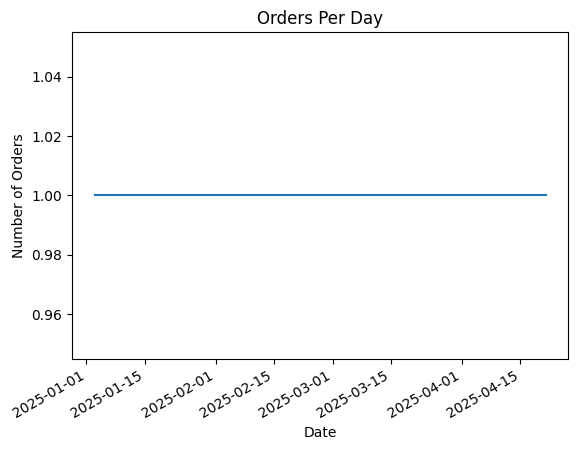

In [32]:
orders_day = df.groupby('OrderDate')['OrderID'].count()

orders_day.plot(kind='line')
plt.title("Orders Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

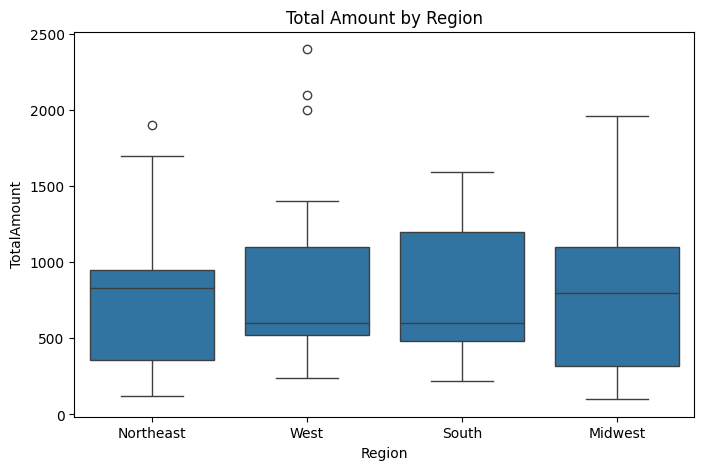

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='TotalAmount', data=df)
plt.title("Total Amount by Region")
plt.show()